# 도메인 광고 운영 전략

도메인별 광고유형 성과, 집행 규모, 이탈 유형 연결
전략 우선유형과 운영 리스크 분리 확인


## 0. 기본 설정

라이브러리, 출력 설정, 한글 폰트


In [95]:
# 라이브러리
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency

# ??? dtype ??? ???
pd.options.future.infer_string = False

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:,.2f}'.format)
# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Malgun Gothic', rc={'axes.unicode_minus': False})


## 1. 데이터 로드

광고 목록, 전환 로그, 클릭 로그 기준 데이터 확인
분석용 도메인/광고유형/단가구간 정리


In [96]:
# CSV 로드 ([광고목록], [광고참여정보], [광고적립])
df_master = pd.read_csv('../domain_master_analysis_compact.csv', encoding='utf-8-sig')
df_engagement = pd.read_csv(
    '../04 ADS/data/cleaned_engagement_data.csv',
    encoding='utf-8-sig',
    usecols=['ads_idx', 'click_key', 'click_date'],
    dtype={
        'ads_idx': 'int32',
        'click_key': 'object',
        'click_date': 'object'
    }
)
df_reward = pd.read_csv(
    '../04 ADS/data/cleaned_reward_data.csv',
    encoding='utf-8-sig',
    usecols=['ads_idx', 'click_key', 'adv_cost', 'click_date'],
    dtype={'ads_idx': 'int32', 'click_key': 'object', 'click_date': 'object'}
)

# 도메인 유형
domain_map = {1: '엔터', 2: '금융', 3: '라이프', 4: '커머스', 5: '기타'} 

# 광고 유형
type_map = {
    1: '설치형', 2: '실행형', 3: '참여형', 4: '클릭형',
    5: '페이스북', 6: '트위터', 7: '인스타그램',
    9: '퀘스트', 10: '유튜브', 11: '네이버', 12: 'CPS(구매)'
}

# 요일
weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}

# 분석용 광고명-도메인-유형 컬럼 생성
df_master['domain_name'] = df_master['domain_label'].map(domain_map).fillna('기타')
df_master['type_name'] = df_master['ads_type'].map(type_map).fillna('기타')
df_master['ads_contract_price'] = pd.to_numeric(df_master['ads_contract_price'], errors='coerce')
df_master['ads_order'] = pd.to_numeric(df_master['ads_order'], errors='coerce')

# 클릭일자 분석 형식 변환
df_engagement['click_date'] = pd.to_datetime(df_engagement['click_date'], errors='coerce')
df_engagement['weekday'] = df_engagement['click_date'].dt.weekday.map(weekday_map)

# 비용과 클릭일자 분석 형식 변환
df_reward['adv_cost'] = pd.to_numeric(df_reward['adv_cost'], errors='coerce').fillna(0)
df_reward['click_date'] = pd.to_datetime(df_reward['click_date'], errors='coerce')
df_reward['weekday'] = df_reward['click_date'].dt.weekday.map(weekday_map)

# 로그 결합용 광고 속성 테이블 생성
ad_cols = ['ads_idx', 'ads_name', 'domain_name', 'type_name', 'ads_contract_price', 'ads_order']
ad_info = df_master[ad_cols].drop_duplicates('ads_idx')




In [97]:
# 규모 확인
print(df_master.shape)
print(df_engagement.shape)
print(df_reward.shape)


(434740, 11)
(10502541, 4)
(934288, 5)


In [98]:
# 샘플 확인
display(df_master[ad_cols].head())


,ads_idx,ads_name,domain_name,type_name,ads_contract_price,ads_order
0,160,리니지레드나이츠,엔터,설치형,170,982800
1,284,강철의함대:Ocean Overlord,엔터,설치형,180,987200
2,292,스노우 SNOW,엔터,설치형,160,987300
3,304,서머너즈 워: 천공의 아레나,엔터,실행형,230,931000
4,1166,테스트_설치형,기타,설치형,1,1973500


## 2. 광고 반응 현황

클릭/전환 발생 여부 기준 반응 광고 구분
무반응 광고의 유형·도메인 집중도 확인


In [99]:
# 목적: 광고별 클릭/전환 성과 통합 테이블 생성
# 기준 데이터: 광고목록(df_master), 광고참여정보(df_engagement), 광고적립(df_reward)
# 0 분모 결측 처리 비율 계산
def safe_div(num, den, scale=1):
    den = pd.Series(den).replace(0, np.nan) if not np.isscalar(den) else (np.nan if den == 0 else den)
    return num / den * scale

# 광고별 클릭 수-기간 집계
click_ad = df_engagement.groupby('ads_idx', as_index=False).agg(
    click_count=('click_key', 'count'),
    first_click=('click_date', 'min'),
    last_click=('click_date', 'max')
)
# 광고별 전환 수-비용 집계
conv_ad = df_reward.groupby('ads_idx', as_index=False).agg(
    conversion_count=('click_key', 'count'),
    total_cost=('adv_cost', 'sum'),
    first_conv=('click_date', 'min'),
    last_conv=('click_date', 'max')
)

# 통합 광고 성과 테이블 생성
total_df = ad_info.merge(click_ad, on='ads_idx', how='left').merge(conv_ad, on='ads_idx', how='left')
total_df[['click_count', 'conversion_count', 'total_cost']] = total_df[['click_count', 'conversion_count', 'total_cost']].fillna(0)
total_df['is_response_ad'] = (total_df['click_count'] > 0) | (total_df['conversion_count'] > 0)
total_df['cvr'] = safe_div(total_df['conversion_count'], total_df['click_count'], 100).fillna(0)
total_df['cpconv'] = safe_div(total_df['total_cost'], total_df['conversion_count']).fillna(0)
total_df['first_event'] = total_df[['first_click', 'first_conv']].min(axis=1)
total_df['last_event'] = total_df[['last_click', 'last_conv']].max(axis=1)
total_df['operation_days'] = (total_df['last_event'] - total_df['first_event']).dt.days.add(1).fillna(0).astype(int)



In [100]:
# 목적: 반응 광고 비율 요약
# 기준 데이터: 통합 광고 성과(total_df)
# 클릭 또는 전환 발생 광고 비율
response = pd.DataFrame({
    '구분': ['반응 광고', '무반응 광고', '전체 공급 광고'],
    '광고 수': [
        int(total_df['is_response_ad'].sum()),
        int((~total_df['is_response_ad']).sum()),
        int(total_df['ads_idx'].nunique())
    ]
})
response['전체 대비 비율(%)'] = safe_div(response['광고 수'], response.loc[2, '광고 수'], 100).round(1)



In [101]:
# 목적: 무반응 광고 유형/도메인 분포 확인
# 기준 데이터: 통합 광고 성과(total_df)
# 클릭-전환 모두 없는 광고 선별
no_response = total_df[~total_df['is_response_ad']]
no_type = (
    no_response.groupby('type_name', as_index=False)
    .agg(ad_count=('ads_idx', 'nunique'))
    .sort_values('ad_count', ascending=False)
)
no_type['무반응 광고 내 점유율(%)'] = safe_div(no_type['ad_count'], no_type['ad_count'].sum(), 100)
no_type = no_type.head(5)

# 최다 무반응 유형의 도메인 분포
main_no_type = no_type.iloc[0]['type_name'] if len(no_type) else None
no_domain = (
    no_response[no_response['type_name'].eq(main_no_type)]
    .groupby('domain_name', as_index=False)
    .agg(ad_count=('ads_idx', 'nunique'))
    .sort_values('ad_count', ascending=False)
)
if len(no_domain):
    no_domain['상위 무반응 유형 내 도메인 점유율(%)'] = safe_div(
        no_domain['ad_count'], no_domain['ad_count'].sum(), 100
    ).round(1)


In [102]:
# 반응 광고 확인
print('반응/무반응 광고 비율')
display(response)


반응/무반응 광고 비율


,구분,광고 수,전체 대비 비율(%)
0,반응 광고,3792,0.90
1,무반응 광고,430948,99.10
2,전체 공급 광고,434740,100.00


In [103]:
# 무반응 유형 확인
print('무반응 광고 유형별 점유율 Top5')
display(no_type)


무반응 광고 유형별 점유율 Top5


,type_name,ad_count,무반응 광고 내 점유율(%)
6,참여형,421296,97.76
2,설치형,6290,1.46
0,CPS(구매),1727,0.40
3,실행형,1128,0.26
5,인스타그램,189,0.04


In [104]:
# 무반응 도메인 확인
print(main_no_type)
display(no_domain)


참여형


,domain_name,ad_count,상위 무반응 유형 내 도메인 점유율(%)
4,커머스,216437,51.40
2,라이프,137653,32.70
1,기타,43580,10.30
3,엔터,20582,4.90
0,금융,3044,0.70


### 공급 광고 유형

전체 공급 광고 수와 유형별 공급 비중 확인


In [105]:
# 광고유형별 공급량과 평균 계약단가 집계
supply = (
    df_master.groupby('type_name', as_index=False)
    .agg(
        ad_count=('ads_idx', 'nunique'),
        avg_contract=('ads_contract_price', 'mean')
    )
    .sort_values('ad_count', ascending=False)
)
supply['supply_share(%)'] = safe_div(supply['ad_count'], supply['ad_count'].sum(), 100)
supply['avg_contract'] = supply['avg_contract'].round(1)

# 공급 비중 산출용 전체 광고 수
total_ads = df_master['ads_idx'].nunique()


In [106]:
# 전체 광고 수
print(total_ads)


434740


In [107]:
# 공급 유형 확인
display(supply[['type_name', 'ad_count', 'supply_share(%)', 'avg_contract']])


,type_name,ad_count,supply_share(%),avg_contract
6,참여형,424513,97.65,42.50
2,설치형,6354,1.46,114.90
0,CPS(구매),2184,0.50,"23,707.60"
3,실행형,1170,0.27,245.10
5,인스타그램,193,0.04,186.80
4,유튜브,188,0.04,158.30
9,페이스북,48,0.01,148.50
1,네이버,36,0.01,148.30
7,클릭형,28,0.01,14.40
8,트위터,26,0.01,75.70


## 3. 전체 퍼널

클릭, 전환, 이탈 규모 확인
전체 CVR 기준 퍼널 손실 규모 파악


In [108]:
# 목적: 전체 클릭-전환-이탈 퍼널 수치 계산
# 기준 데이터: 광고참여정보(df_engagement), 광고적립(df_reward)
# 클릭 로그와 전환 로그 기준 수치 계산
total_click = len(df_engagement)
total_conv = len(df_reward)
total_churn = total_click - total_conv
total_cvr = safe_div(total_conv, total_click, 100)

# 퍼널 지표 표시용 테이블 생성
funnel = pd.DataFrame({
    'metric': ['click_count', 'conversion_count', 'lost_click', 'cvr(%)'],
    'value': [total_click, total_conv, total_churn, round(float(total_cvr), 2)]
})
display(funnel)


,metric,value
0,click_count,"10,502,541.00"
1,conversion_count,"934,288.00"
2,lost_click,"9,568,253.00"
3,cvr(%),8.90


### 전체 퍼널 시각화

클릭 대비 전환·이탈 규모 비교


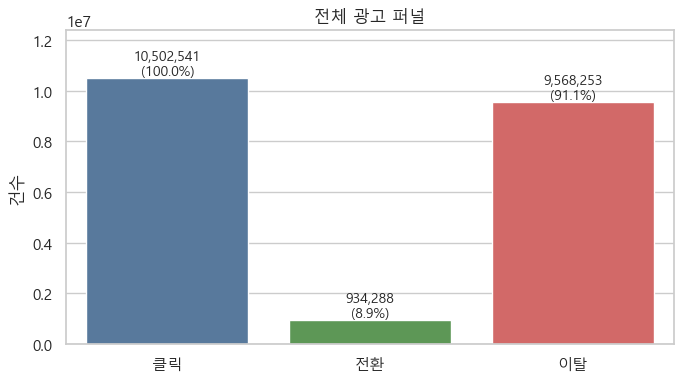

In [109]:
# 클릭 대비 전환/이탈 비율 포함 퍼널 시각화
fig, ax = plt.subplots(figsize=(7, 4))
# 퍼널 단계별 건수 테이블 생성
funnel_plot = pd.DataFrame({'단계': ['클릭', '전환', '이탈'], '건수': [total_click, total_conv, total_churn]})
funnel_plot['클릭 대비 비율(%)'] = safe_div(funnel_plot['건수'], total_click, 100).round(1)
sns.barplot(data=funnel_plot, x='단계', y='건수', hue='단계', palette=['#4C78A8', '#54A24B', '#E45756'], legend=False, ax=ax)
for patch, (_, row) in zip(ax.patches, funnel_plot.iterrows()):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height(),
        f"{row['건수']:,.0f}\n({row['클릭 대비 비율(%)']:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )
ax.margins(y=0.18)
ax.set_title('전체 광고 퍼널')
ax.set_xlabel('')
ax.set_ylabel('건수')
plt.tight_layout()
plt.show()


## 4. 도메인 x 광고유형

도메인별 전환 기여와 예산 소화 구조 확인
전략 중요도 산정용 기본 테이블


In [110]:
# 목적: 도메인-유형별 클릭/전환/비용 성과 비교
# 기준 데이터: 통합 광고 성과(total_df), 광고적립(df_reward), 광고목록(df_master)
# 전환 로그에 광고 속성 연결
conversion_df = df_reward.merge(ad_info, on='ads_idx', how='left')

# 도메인-유형별 클릭 합계
click_type = (
    total_df.groupby(['domain_name', 'type_name'], as_index=False)
    .agg(click_count=('click_count', 'sum'))
)
# 도메인-유형별 전환-비용 합계
conv_type = (
    conversion_df.groupby(['domain_name', 'type_name'], as_index=False)
    .agg(
        conversion_count=('click_key', 'count'),
        total_spent=('adv_cost', 'sum'),
        ad_count=('ads_idx', 'nunique')
    )
)

# 클릭-전환 합계 테이블
combo = conv_type.merge(click_type, on=['domain_name', 'type_name'], how='left')
combo['click_count'] = combo['click_count'].fillna(0)
# CPA-CVR-광고당 전환 비교
combo['cpconv'] = safe_div(combo['total_spent'], combo['conversion_count']).fillna(0)
combo['cvr'] = safe_div(combo['conversion_count'], combo['click_count'], 100).fillna(0)
combo['conv_per_ad'] = safe_div(combo['conversion_count'], combo['ad_count']).fillna(0)
# 도메인 내부 전환/예산 점유율 계산
combo['conversion_share'] = combo.groupby('domain_name')['conversion_count'].transform(lambda x: safe_div(x, x.sum(), 100))
combo['budget_share'] = combo.groupby('domain_name')['total_spent'].transform(lambda x: safe_div(x, x.sum(), 100))



In [111]:
# 목적: 도메인-유형별 성과 미리보기
# 기준 데이터: 도메인-유형별 성과(combo)
# 결과 확인
display(
    combo.sort_values(['domain_name', 'conversion_count'], ascending=[True, False])
    [['domain_name', 'type_name', 'conversion_count', 'click_count', 'conversion_share', 'budget_share', 'cvr', 'cpconv', 'conv_per_ad']]
    .head(30)
)


,domain_name,type_name,conversion_count,click_count,conversion_share,budget_share,cvr,cpconv,conv_per_ad
1,금융,실행형,43553,"315,881.00",89.72,62.22,13.79,254.95,"6,221.86"
3,금융,참여형,3157,"47,268.00",6.50,35.86,6.68,"2,027.09",78.92
0,금융,설치형,1532,"12,895.00",3.16,1.58,11.88,184.26,383.00
2,금융,유튜브,300,731.00,0.62,0.34,41.04,200.00,300.00
6,기타,참여형,3172,"1,677,580.00",31.92,33.04,0.19,223.39,16.61
5,기타,실행형,2791,"10,440.00",28.09,29.93,26.73,230.00,398.71
4,기타,설치형,2773,"4,045.00",27.91,22.63,68.55,175.05,346.62
7,기타,페이스북,1201,"4,196.00",12.09,14.39,28.62,257.00,"1,201.00"
9,라이프,실행형,35181,"119,107.00",67.57,47.55,29.54,219.89,"4,397.62"
8,라이프,설치형,10962,"18,892.00",21.06,11.71,58.02,173.81,"1,370.25"


### 전환 비중

광고유형별·도메인별 전환 기여 비중 비교


,type_name,conversion_share(%),conversion_count,cpconv,conv_per_ad
3,실행형,48.81,454338,272.31,"11,649.69"
2,설치형,41.50,386282,168.79,"6,035.66"
6,참여형,5.16,47994,682.28,33.01
1,네이버,2.08,19366,230.00,"9,683.00"
5,인스타그램,1.29,11989,227.51,"2,997.25"
0,CPS(구매),0.56,5198,"43,285.63",74.26
7,클릭형,0.38,3570,10.33,"1,190.00"
8,페이스북,0.13,1201,257.00,"1,201.00"


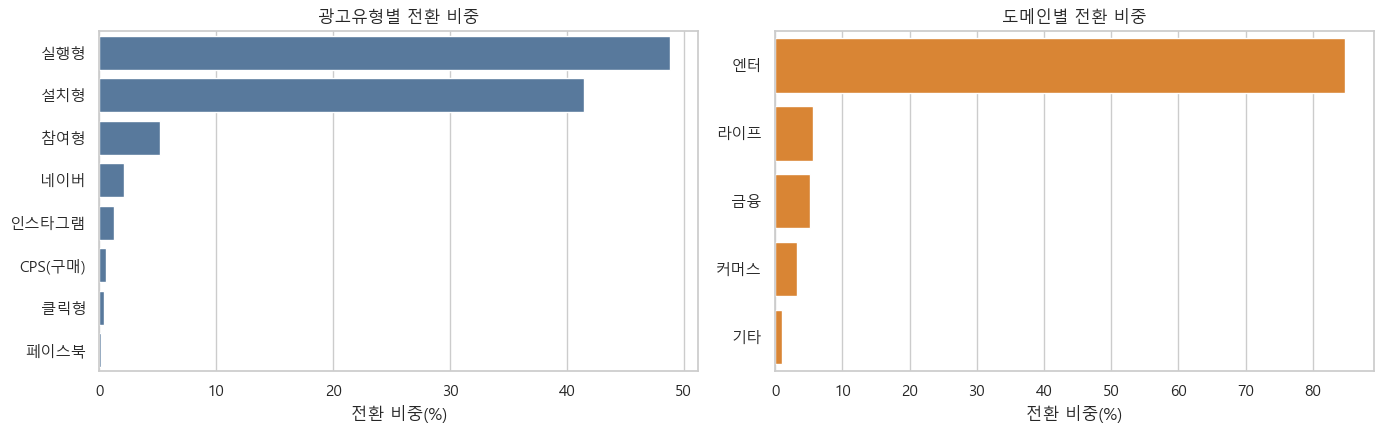

In [112]:
# 전체 전환의 광고유형/도메인 점유율 확인
type_share_plot = (
    combo.groupby('type_name', as_index=False)
    .agg(
        conversion_count=('conversion_count', 'sum'),
        total_spent=('total_spent', 'sum'),
        ad_count=('ad_count', 'sum')
    )
    .sort_values('conversion_count', ascending=False)
)
type_share_plot['conversion_share(%)'] = safe_div(type_share_plot['conversion_count'], type_share_plot['conversion_count'].sum(), 100)
type_share_plot['cpconv'] = safe_div(type_share_plot['total_spent'], type_share_plot['conversion_count']).fillna(0)
type_share_plot['conv_per_ad'] = safe_div(type_share_plot['conversion_count'], type_share_plot['ad_count']).fillna(0)

display(type_share_plot[['type_name', 'conversion_share(%)', 'conversion_count', 'cpconv', 'conv_per_ad']].head(8))

domain_share_plot = combo.groupby('domain_name', as_index=False).agg(conversion_count=('conversion_count', 'sum')).sort_values('conversion_count', ascending=False)
domain_share_plot['conversion_share(%)'] = safe_div(domain_share_plot['conversion_count'], domain_share_plot['conversion_count'].sum(), 100)

# 광고유형/도메인 전환 점유율 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=type_share_plot.head(8), x='conversion_share(%)', y='type_name', color='#4C78A8', ax=axes[0])
axes[0].set_title('광고유형별 전환 비중')
axes[0].set_xlabel('전환 비중(%)')
axes[0].set_ylabel('')

sns.barplot(data=domain_share_plot, x='conversion_share(%)', y='domain_name', color='#F58518', ax=axes[1])
axes[1].set_title('도메인별 전환 비중')
axes[1].set_xlabel('전환 비중(%)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


### 성과 히트맵

전환 기여 비중 기준 도메인별 운영 중심 유형 확인


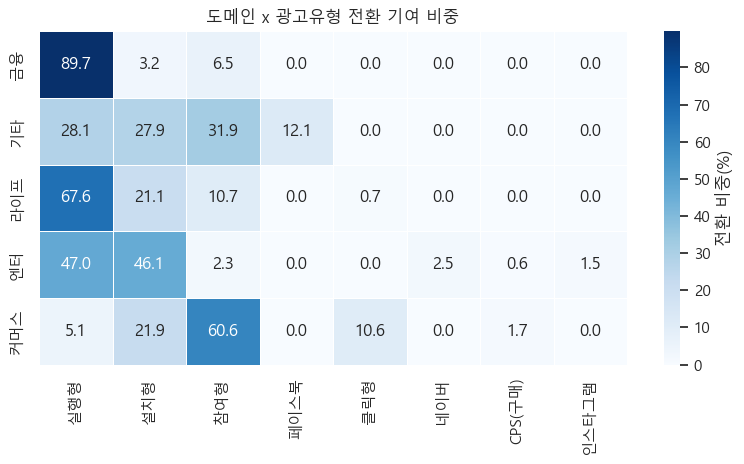

In [113]:
# 목적: 도메인별 광고유형 전환 기여도 히트맵 생성
# 기준 데이터: 전환 분석 데이터(conversion_df)
# 도메인별 유형 전환 점유율 행렬
conv_heat = combo.pivot_table(index='domain_name', columns='type_name', values='conversion_share', aggfunc='sum').fillna(0)

# 전환 규모 작은 유형 제외
heat_cols = conv_heat.sum().sort_values(ascending=False).head(8).index
conv_heat = conv_heat.reindex(columns=heat_cols).fillna(0)

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.heatmap(conv_heat, annot=True, fmt='.1f', cmap='Blues', linewidths=.5, cbar_kws={'label': '전환 비중(%)'}, ax=ax)
ax.set_title('도메인 x 광고유형 전환 기여 비중')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 5. 도메인별 단가 조합

전환 발생 광고 기준 도메인·광고유형·단가구간 비교
예산 규모 해석용 보조 근거


In [114]:
# 목적: 계약단가 구간별 전환 효율 조합 확인
# 기준 데이터: 전환 분석 데이터(conversion_df), 광고목록(df_master)
# 계약단가 기준 구간 분류
def price_segment(price):
    if pd.isna(price):
        return '미상'
    if price <= 50:
        return '저단가(1~50)'
    if price <= 200:
        return '중단가(51~200)'
    if price <= 500:
        return '고단가(201~500)'
    return '프리미엄(501+)'

# 전환 로그에 단가 구간 부여
reward_price = conversion_df.copy()
reward_price['price_segment'] = reward_price['ads_contract_price'].apply(price_segment)

# 도메인-유형-단가구간별 전환 집계
price_group = (
    reward_price.groupby(['domain_name', 'type_name', 'price_segment'], as_index=False)
    .agg(
        conversion_count=('click_key', 'count'),
        total_spent=('adv_cost', 'sum'),
        ad_count=('ads_idx', 'nunique')
    )
)
# 단가구간별 CPA-광고당 전환 계산
price_group['cpconv'] = safe_div(price_group['total_spent'], price_group['conversion_count']).fillna(0)
price_group['conv_per_ad'] = safe_div(price_group['conversion_count'], price_group['ad_count']).fillna(0)
# 도메인별 전환 많은 단가 조합 선택
price_top = (
    price_group.sort_values(['domain_name', 'conversion_count', 'cpconv'], ascending=[True, False, True])
    .groupby('domain_name', as_index=False)
    .head(3)
)


In [115]:
# 단가 조합 확인
print('단가 조합')
display(price_top[['domain_name', 'type_name', 'price_segment', 'conversion_count', 'ad_count', 'cpconv', 'conv_per_ad']])


단가 조합


,domain_name,type_name,price_segment,conversion_count,ad_count,cpconv,conv_per_ad
1,금융,실행형,고단가(201~500),43553,7,254.95,"6,221.86"
5,금융,참여형,프리미엄(501+),2319,31,"2,750.53",74.81
0,금융,설치형,중단가(51~200),1532,4,184.26,383.00
8,기타,실행형,고단가(201~500),2791,7,230.00,398.71
7,기타,설치형,중단가(51~200),2767,5,175.41,553.40
9,기타,참여형,고단가(201~500),1866,3,282.73,622.00
15,라이프,실행형,고단가(201~500),23330,5,230.00,"4,666.00"
16,라이프,실행형,중단가(51~200),11851,3,200.00,"3,950.33"
14,라이프,설치형,중단가(51~200),10962,8,173.81,"1,370.25"
26,엔터,실행형,고단가(201~500),371262,11,279.81,"33,751.09"


### 운영 타이밍

요일별 최저 CPA와 80% 전환 도달 기간 확인


In [116]:
# 목적: 요일별 전환 비용과 전환 집중 시점 확인
# 기준 데이터: 전환 분석 데이터(conversion_df)
# 도메인-요일별 전환당 비용 계산
weekday = (
    conversion_df.groupby(['domain_name', 'weekday'], as_index=False)
    .agg(conversion_count=('click_key', 'count'), total_spent=('adv_cost', 'sum'))
)
weekday['cpconv'] = safe_div(weekday['total_spent'], weekday['conversion_count']).fillna(0)
# 전환 100건 이상 요일만 최저 CPA 선택
weekday_best = (
    weekday[weekday['conversion_count'] >= 100]
    .sort_values(['domain_name', 'cpconv'], ascending=[True, True])
    .groupby('domain_name', as_index=False)
    .head(1)
)



In [117]:
# 목적: 누적 전환 80% 도달 시점 계산
# 기준 데이터: 전환 분석 데이터(conversion_df)
# 광고별 시작일 기준 경과일 계산
life = conversion_df.dropna(subset=['click_date']).copy()
life['start_date'] = life.groupby('ads_idx')['click_date'].transform('min')
life['day_from_start'] = (life['click_date'].dt.normalize() - life['start_date'].dt.normalize()).dt.days + 1
# 도메인별 경과일 전환 집계
life_daily = (
    life.groupby(['domain_name', 'day_from_start'], as_index=False)
    .agg(conversion_count=('click_key', 'count'))
    .sort_values(['domain_name', 'day_from_start'])
)
# 도메인별 누적 전환 비중 계산
life_daily['cum_conv'] = life_daily.groupby('domain_name')['conversion_count'].cumsum()
life_daily['total_conv'] = life_daily.groupby('domain_name')['conversion_count'].transform('sum')
life_daily['cum_share'] = safe_div(life_daily['cum_conv'], life_daily['total_conv'], 100)
# 누적 전환 80% 도달 경과일 선택
p80 = life_daily[life_daily['cum_share'] >= 80].copy()
p80 = p80.sort_values(['domain_name', 'day_from_start'])
p80 = p80.groupby('domain_name', as_index=False).head(1)
p80 = p80[['domain_name', 'day_from_start', 'cum_share']]
p80 = p80.rename(columns={
    'day_from_start': 'p80_conversion_day',
    'cum_share': '누적전환비중(%)'
})
p80['누적전환비중(%)'] = p80['누적전환비중(%)'].round(1)


In [118]:
# 최저 CPA 요일
print('최저 CPA 요일')
display(weekday_best[['domain_name', 'weekday', 'conversion_count', 'cpconv']])


최저 CPA 요일


,domain_name,weekday,conversion_count,cpconv
0,금융,금,8569,319.80
12,기타,토,1393,207.81
17,라이프,월,9265,216.32
23,엔터,수,141794,266.34
30,커머스,수,5352,715.26


In [119]:
# 80% 전환일
print('80% 전환일')
display(p80)


80% 전환일


,domain_name,p80_conversion_day,누적전환비중(%)
18,금융,19,83.90
48,기타,18,82.00
87,라이프,27,80.60
101,엔터,10,81.50
134,커머스,12,81.00


## 6. 예산 규모별 운영 패턴

광고별 실제 집행비 기준 예산구간 분리
도메인별 대표 예산구간·광고유형 조합 확인


In [120]:
# 목적: 광고별 총집행비 구간에 따른 유형 효율 확인
# 기준 데이터: 통합 광고 성과(total_df)
# 광고별 총집행비 기준 구간 분류
def spend_band(total_spent):
    if total_spent <= 100_000:
        return '소규모(~10만)'
    if total_spent <= 500_000:
        return '중규모(10~50만)'
    if total_spent <= 2_000_000:
        return '대규모(50~200만)'
    return '초대형(200만+)'

# 광고별 총집행비 구간 부여
total_df['spend_band'] = total_df['total_cost'].apply(spend_band)
band_order = ['소규모(~10만)', '중규모(10~50만)', '대규모(50~200만)', '초대형(200만+)']

# 집행비구간-유형별 CPA와 광고당 전환 계산
spend_eff = (
    total_df[total_df['conversion_count'] > 0]
    .groupby(['spend_band', 'type_name'], as_index=False)
    .agg(
        ad_count=('ads_idx', 'nunique'),
        conversion_count=('conversion_count', 'sum'),
        total_spent=('total_cost', 'sum')
    )
)
spend_eff['cpa'] = safe_div(spend_eff['total_spent'], spend_eff['conversion_count']).fillna(0)
spend_eff['avg_conv_per_ad'] = safe_div(spend_eff['conversion_count'], spend_eff['ad_count']).fillna(0)
spend_eff['spend_band'] = pd.Categorical(spend_eff['spend_band'], categories=band_order, ordered=True)
spend_top = (
    spend_eff.sort_values(['spend_band', 'conversion_count', 'cpa'], ascending=[True, False, True])
    .groupby('spend_band', as_index=False)
    .head(3)
)



In [121]:
# 목적: 도메인별 집행비구간-유형 효율 계산
# 기준 데이터: 통합 광고 성과(total_df)
# 도메인-집행비구간-유형별 효율 계산
domain_spend_eff = (
    total_df[total_df['conversion_count'] > 0]
    .groupby(['domain_name', 'spend_band', 'type_name'], as_index=False)
    .agg(
        ad_count=('ads_idx', 'nunique'),
        conversion_count=('conversion_count', 'sum'),
        total_spent=('total_cost', 'sum')
    )
)
domain_spend_eff['cpa'] = safe_div(domain_spend_eff['total_spent'], domain_spend_eff['conversion_count']).fillna(0)
domain_spend_eff['avg_conv_per_ad'] = safe_div(domain_spend_eff['conversion_count'], domain_spend_eff['ad_count']).fillna(0)


In [122]:
# 집행비 구간 확인
print('집행비 구간별 효율 상위 광고유형')
display(spend_top[['spend_band', 'type_name', 'ad_count', 'conversion_count', 'cpa', 'avg_conv_per_ad']])


집행비 구간별 효율 상위 광고유형


,spend_band,type_name,ad_count,conversion_count,cpa,avg_conv_per_ad
10,소규모(~10만),참여형,1416,"27,177.00",120.86,19.19
7,소규모(~10만),설치형,22,"3,622.00",170.15,164.64
11,소규모(~10만),클릭형,3,"3,570.00",10.33,"1,190.00"
13,중규모(10~50만),설치형,20,"27,701.00",166.83,"1,385.05"
14,중규모(10~50만),실행형,7,"8,220.00",239.83,"1,174.29"
17,중규모(10~50만),참여형,17,"5,176.00",929.47,304.47
2,대규모(50~200만),설치형,13,"76,243.00",168.76,"5,864.85"
3,대규모(50~200만),실행형,8,"35,607.00",226.45,"4,450.88"
5,대규모(50~200만),참여형,20,"12,953.00","1,487.98",647.65
22,초대형(200만+),실행형,8,"408,832.00",277.16,"51,104.00"


### 도메인 운영 메모

엔터 초대형·설치형 중심, 라이프 초대형·실행형 중심
금융 대규모·설치형, 커머스 소규모 클릭형·참여형 확인


### 집행비 구간 시각화

예산구간별 CPA와 광고당 전환수 비교


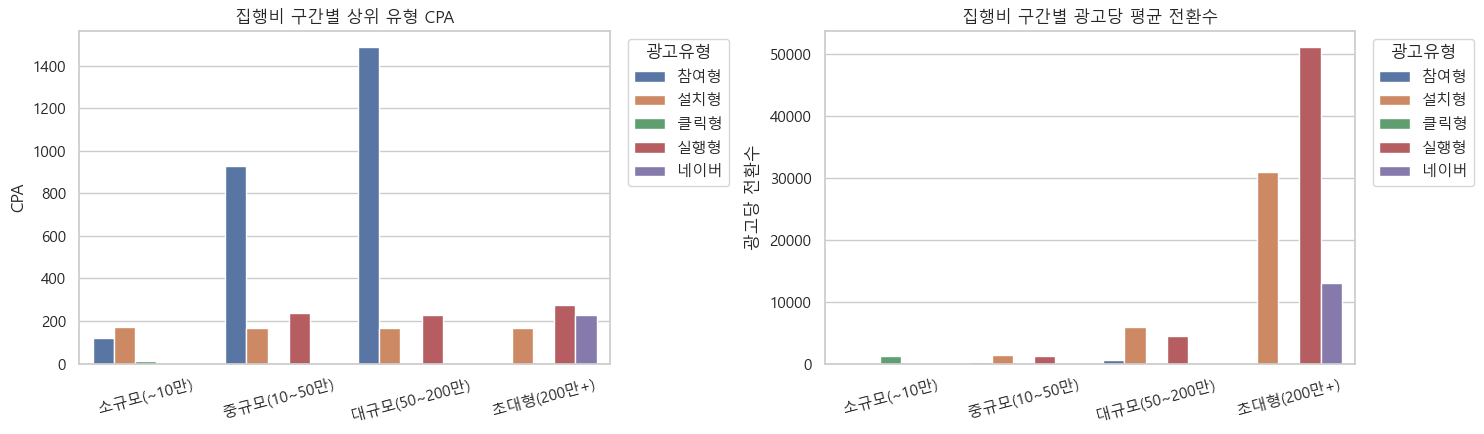

In [123]:
# 목적: 집행비구간별 상위 유형 효율 시각화
# 기준 데이터: 집행비구간 효율 결과(spend_top)
# 상위 집행비구간 결과 시각화용 복사
spend_plot = spend_top.copy()
spend_plot['spend_band'] = spend_plot['spend_band'].astype(str)
# 집행비구간별 CPA와 광고당 전환 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(data=spend_plot, x='spend_band', y='cpa', hue='type_name', ax=axes[0])
axes[0].set_title('집행비 구간별 상위 유형 CPA')
axes[0].set_xlabel('')
axes[0].set_ylabel('CPA')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='광고유형', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.barplot(data=spend_plot, x='spend_band', y='avg_conv_per_ad', hue='type_name', ax=axes[1])
axes[1].set_title('집행비 구간별 광고당 평균 전환수')
axes[1].set_xlabel('')
axes[1].set_ylabel('광고당 전환수')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='광고유형', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 7. 통계 검증

도메인별·광고유형별 전환 구조 차이가 전략 점수화의 근거가 될 수 있는지 확인


In [124]:
# 목적: 도메인/광고유형 전환 분포 차이 검정
# 기준 데이터: 전환 분석 데이터(conversion_df)

conversion_table = pd.crosstab(conversion_df['domain_name'], conversion_df['type_name'])
chi2, p_value, dof, expected = chi2_contingency(conversion_table)
cramers_v = np.sqrt(chi2 / (conversion_table.to_numpy().sum() * (min(conversion_table.shape) - 1)))


In [125]:
# 목적: 커머스 내부 광고유형별 전환 구조 검정
# 기준 데이터: 통합 광고 성과(total_df)

commerce_ads = total_df[total_df['domain_name'].eq('커머스')].copy()
commerce_cvr = (
    commerce_ads.groupby('type_name', as_index=False)
    .agg(click_count=('click_count', 'sum'), conversion_count=('conversion_count', 'sum'))
)
commerce_cvr = commerce_cvr[commerce_cvr['click_count'] > 0]
commerce_cvr['non_conversion_count'] = commerce_cvr['click_count'] - commerce_cvr['conversion_count']
commerce_cvr['cvr(%)'] = safe_div(commerce_cvr['conversion_count'], commerce_cvr['click_count'], 100).round(2)
commerce_cvr = commerce_cvr.sort_values('conversion_count', ascending=False)

commerce_table = commerce_cvr.set_index('type_name')[['conversion_count', 'non_conversion_count']]
commerce_chi2, commerce_p, commerce_dof, commerce_expected = chi2_contingency(commerce_table)
commerce_cramers_v = np.sqrt(commerce_chi2 / (commerce_table.to_numpy().sum() * (min(commerce_table.shape) - 1)))


In [126]:
# 목적: 도메인별 전환이 특정 광고유형에 유의하게 치우치는지 확인

domain_type_test_result = pd.DataFrame([{
    '검정': '도메인 × 광고유형 전환 분포',
    'chi-square': round(chi2, 1),
    'dof': int(dof),
    'p-value': f'{p_value:.3e}',
    "Cramer's V": round(cramers_v, 3)
}])


In [127]:
# 도메인/광고유형 전환 분포 검정 결과
display(domain_type_test_result)


,검정,chi-square,dof,p-value,Cramer's V
0,도메인 × 광고유형 전환 분포,"478,655.60",32,0.000e+00,0.36


In [128]:
# 목적: 커머스 도메인 안에서 광고유형별 전환/미전환 구조 차이가 유의한지 확인

commerce_type_test_result = pd.DataFrame([{
    '검정': '커머스 내부 광고유형별 전환 구조',
    'chi-square': round(commerce_chi2, 1),
    'dof': int(commerce_dof),
    'p-value': f'{commerce_p:.3e}',
    "Cramer's V": round(commerce_cramers_v, 3)
}])


In [129]:
# 커머스 내부 광고유형별 전환 구조 검정 결과
display(commerce_type_test_result)


,검정,chi-square,dof,p-value,Cramer's V
0,커머스 내부 광고유형별 전환 구조,"13,745.60",4,0.000e+00,0.35


## 8. 전략 점수 로직


In [130]:
# 도메인별 추천 광고유형 Top3를 만든다.
strategy_view = combo.copy()
strategy_view['score'] = np.sqrt(strategy_view['conversion_share'] * strategy_view['budget_share'])
strategy_view['rank'] = (
    strategy_view.sort_values(['domain_name', 'score', 'conversion_count'], ascending=[True, False, False])
    .groupby('domain_name')
    .cumcount() + 1
)

strategy_view = (
    strategy_view[strategy_view['rank'] <= 3]
    .sort_values(['domain_name', 'rank'])
    [['domain_name', 'rank', 'type_name', 'conversion_share', 'budget_share',
      'conversion_count', 'cvr', 'conv_per_ad', 'score']]
    .copy()
)
strategy_view[['conversion_share', 'budget_share', 'cvr', 'conv_per_ad', 'score']] = (
    strategy_view[['conversion_share', 'budget_share', 'cvr', 'conv_per_ad', 'score']].round(2)
)


In [131]:
# 도메인별 추천 광고유형 Top3를 확인한다.
display(strategy_view)


,domain_name,rank,type_name,conversion_share,budget_share,conversion_count,cvr,conv_per_ad,score
1,금융,1,실행형,89.72,62.22,43553,13.79,"6,221.86",74.72
3,금융,2,참여형,6.50,35.86,3157,6.68,78.92,15.27
0,금융,3,설치형,3.16,1.58,1532,11.88,383.00,2.23
6,기타,1,참여형,31.92,33.04,3172,0.19,16.61,32.48
5,기타,2,실행형,28.09,29.93,2791,26.73,398.71,28.99
4,기타,3,설치형,27.91,22.63,2773,68.55,346.62,25.13
9,라이프,1,실행형,67.57,47.55,35181,29.54,"4,397.62",56.68
10,라이프,2,참여형,10.66,40.72,5549,7.87,10.14,20.83
8,라이프,3,설치형,21.06,11.71,10962,58.02,"1,370.25",15.70
15,엔터,1,실행형,46.99,30.45,371263,49.86,"30,938.58",37.83


## 9. 운영 리스크 유형


In [132]:
# 미전환 클릭 손실이 가장 큰 광고유형을 운영 리스크로 본다.
caution_base = total_df[(total_df['click_count'] > 0) & (total_df['conversion_count'] == 0)].copy()

caution_type = (
    caution_base.groupby(['domain_name', 'type_name'], as_index=False)
    .agg(caution_ad_count=('ads_idx', 'nunique'), lost_click=('click_count', 'sum'))
    .sort_values(['domain_name', 'lost_click', 'caution_ad_count'], ascending=[True, False, False])
    .groupby('domain_name', as_index=False)
    .head(1)
    .rename(columns={'type_name': 'caution_type'})
    [['domain_name', 'caution_type', 'caution_ad_count', 'lost_click']]
    .sort_values('domain_name')
    .reset_index(drop=True)
)
caution_type[['caution_ad_count', 'lost_click']] = caution_type[['caution_ad_count', 'lost_click']].astype(int)



In [133]:
# 도메인별 운영 리스크 유형을 확인한다.
display(caution_type)


,domain_name,caution_type,caution_ad_count,lost_click
0,금융,참여형,50,6223
1,기타,참여형,181,1631310
2,라이프,참여형,848,3585
3,엔터,참여형,172,1581439
4,커머스,CPS(구매),335,2002


## 10. 대표 우수 광고 사례


In [134]:
# 1순위 추천 유형 안에서 전환 성과가 가장 좋은 광고를 고른다.
recommended_type = (
    strategy_view[strategy_view['rank'] == 1]
    .rename(columns={'type_name': 'recommended_type'})
    [['domain_name', 'recommended_type']]
)

success_case = (
    total_df.merge(
        recommended_type,
        left_on=['domain_name', 'type_name'],
        right_on=['domain_name', 'recommended_type'],
        how='inner'
    )
    .query('conversion_count > 0')
    .sort_values(['domain_name', 'conversion_count', 'cvr'], ascending=[True, False, False])
    .groupby('domain_name', as_index=False)
    .head(1)
    .rename(columns={'ads_name': 'success_case_ad'})
    [['domain_name', 'recommended_type', 'success_case_ad',
      'conversion_count', 'cvr', 'cpconv', 'operation_days']]
    .copy()
)
success_case[['cvr', 'cpconv']] = success_case[['cvr', 'cpconv']].round(2)


In [135]:
# 추천 유형, 대표 사례, 리스크 유형을 최종 표로 묶는다.
case_table = (
    recommended_type
    .merge(success_case, on=['domain_name', 'recommended_type'], how='left')
    .merge(caution_type[['domain_name', 'caution_type', 'lost_click']], on='domain_name', how='left')
    [['domain_name', 'recommended_type', 'success_case_ad', 'conversion_count',
      'cvr', 'cpconv', 'operation_days', 'caution_type', 'lost_click']]
)


In [136]:
# 도메인별 대표 우수 광고 사례를 확인한다.
display(case_table)


,domain_name,recommended_type,success_case_ad,conversion_count,cvr,cpconv,operation_days,caution_type,lost_click
0,금융,실행형,[오픈하기] KB차차차,"31,123.00",15.25,260.00,21,참여형,6223
1,기타,참여형,충청남도 페이스북,"1,821.00",20.84,280.00,28,참여형,1631310
2,라이프,실행형,알바천국,"10,788.00",15.52,230.00,31,참여형,3585
3,엔터,실행형,K데몬헌터스,"105,702.00",61.44,280.00,5,참여형,1581439
4,커머스,참여형,쿠팡 출석체크 [재참여가능],"8,648.00",88.91,5.00,29,CPS(구매),2002


## Streamlit 광고 전략 추천 CSV 저장

메인 분석 셀에서 이미 계산한 `total_df`, `p80`, `strategy_view`, `price_group`을 사용해 대시보드용 CSV 3종을 저장합니다.

- `advertiser_strategy_master.csv`
- `ad_lifecycle_summary.csv`
- `domain_recommendation.csv`


In [137]:
# Streamlit 대시보드 CSV 저장
import os
import pandas as pd

# 저장 경로
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

# 필수 결과 확인
required_tables = ["total_df", "p80", "strategy_view", "price_group", "df_master", "df_engagement", "df_reward"]
missing_tables = [name for name in required_tables if name not in globals()]
if missing_tables:
    raise NameError(f"필수 중간 결과가 없습니다: {', '.join(missing_tables)}")

# 광고 전략 마스터
advertiser_strategy_master = total_df.copy()

# 광고유형 코드 보정
if "ads_type" not in advertiser_strategy_master.columns:
    ads_type_map = df_master[["ads_idx", "ads_type"]].drop_duplicates("ads_idx")
    advertiser_strategy_master = advertiser_strategy_master.merge(ads_type_map, on="ads_idx", how="left")

# 단가구간 보정
if "price_segment" not in advertiser_strategy_master.columns:
    if "price_segment" in globals():
        advertiser_strategy_master["price_segment"] = advertiser_strategy_master["ads_contract_price"].apply(price_segment)
    else:
        advertiser_strategy_master["price_segment"] = "미상"

# 기준일 보정
advertiser_strategy_master["date"] = pd.to_datetime(
    advertiser_strategy_master["first_event"].combine_first(advertiser_strategy_master["last_event"]),
    errors="coerce"
).dt.date

# 요일 보정
base_date = pd.to_datetime(advertiser_strategy_master["date"], errors="coerce")
if "weekday_map" in globals():
    advertiser_strategy_master["weekday"] = base_date.dt.weekday.map(weekday_map)
else:
    advertiser_strategy_master["weekday"] = base_date.dt.day_name()

# 지표명 정리
advertiser_strategy_master["click_cnt"] = pd.to_numeric(
    advertiser_strategy_master["click_count"], errors="coerce"
).fillna(0).astype(int)
advertiser_strategy_master["conv_cnt"] = pd.to_numeric(
    advertiser_strategy_master["conversion_count"], errors="coerce"
).fillna(0).astype(int)
advertiser_strategy_master["total_cost"] = pd.to_numeric(
    advertiser_strategy_master["total_cost"], errors="coerce"
).fillna(0)
advertiser_strategy_master["non_conv_cnt"] = (
    advertiser_strategy_master["click_cnt"] - advertiser_strategy_master["conv_cnt"]
).clip(lower=0).astype(int)

# 전체 KPI 원천값
kpi_click_cnt = len(df_engagement)
kpi_conv_cnt = len(df_reward)
advertiser_strategy_master["kpi_click_cnt"] = kpi_click_cnt
advertiser_strategy_master["kpi_conv_cnt"] = kpi_conv_cnt
advertiser_strategy_master["kpi_non_conv_cnt"] = kpi_click_cnt - kpi_conv_cnt

# 클릭 발생 광고
advertiser_strategy_master = advertiser_strategy_master[advertiser_strategy_master["click_cnt"] > 0].copy()

# 컬럼명 정리
advertiser_strategy_master = advertiser_strategy_master.rename(columns={
    "ads_idx": "ad_id",
    "domain_name": "domain",
    "type_name": "ads_type_name",
})

# 컬럼 선택
advertiser_strategy_master = advertiser_strategy_master[[
    "ad_id", "ads_name", "domain", "ads_type", "ads_type_name", "date", "weekday",
    "price_segment", "total_cost", "click_cnt", "conv_cnt", "non_conv_cnt",
    "kpi_click_cnt", "kpi_conv_cnt", "kpi_non_conv_cnt"
]]

# CSV 저장
advertiser_strategy_master.to_csv(
    f"{output_dir}/advertiser_strategy_master.csv",
    index=False,
    encoding="utf-8-sig"
)

# 라이프사이클 요약
ad_lifecycle_summary = p80.copy()
ad_lifecycle_summary = ad_lifecycle_summary.rename(columns={
    "domain_name": "domain",
    "p80_conversion_day": "p80_day",
})
ad_lifecycle_summary = ad_lifecycle_summary[["domain", "p80_day"]].copy()
ad_lifecycle_summary["p80_day"] = pd.to_numeric(ad_lifecycle_summary["p80_day"], errors="coerce")

# CSV 저장
ad_lifecycle_summary.to_csv(
    f"{output_dir}/ad_lifecycle_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

# 추천 단가 조합
price_recommend = price_group.copy()
price_recommend = price_recommend.sort_values(
    ["domain_name", "type_name", "conversion_count", "cpconv"],
    ascending=[True, True, False, True]
)
price_recommend = price_recommend.drop_duplicates(["domain_name", "type_name"])
price_recommend = price_recommend[["domain_name", "type_name", "price_segment"]]
price_recommend = price_recommend.rename(columns={"price_segment": "recommended_price_segment"})

# 광고유형 코드표
ads_type_code = df_master[["ads_type", "type_name"]].dropna(subset=["type_name"])
ads_type_code = ads_type_code.drop_duplicates("type_name")
ads_type_code = ads_type_code.rename(columns={
    "ads_type": "recommended_type_code",
    "type_name": "recommended_type",
})

# 전략 메시지
message_map = {
    "엔터": "대규모 전환 확보에 적합",
    "커머스": "안정적 효율 운영에 적합",
    "금융": "장기 숙고형 전환에 적합",
    "라이프": "안정형 장기 운영에 적합",
    "기타": "테스트 예산으로 성과 검증에 적합",
}

# 추천 전략 테이블
domain_recommendation = strategy_view.copy()
domain_recommendation = domain_recommendation.rename(columns={
    "domain_name": "domain",
    "type_name": "recommended_type",
})
domain_recommendation = domain_recommendation.merge(
    price_recommend.rename(columns={"domain_name": "domain", "type_name": "recommended_type"}),
    on=["domain", "recommended_type"],
    how="left"
)
domain_recommendation = domain_recommendation.merge(
    ads_type_code,
    on="recommended_type",
    how="left"
)
domain_recommendation["strategy_message"] = domain_recommendation["domain"].map(message_map).fillna(message_map["기타"])
domain_recommendation["recommended_price_segment"] = domain_recommendation["recommended_price_segment"].fillna("미상")

# 컬럼 선택
domain_recommendation = domain_recommendation[[
    "domain", "rank", "recommended_type_code", "recommended_type",
    "recommended_price_segment", "strategy_message"
]]

# CSV 저장
domain_recommendation.to_csv(
    f"{output_dir}/domain_recommendation.csv",
    index=False,
    encoding="utf-8-sig"
)

print("[Streamlit CSV 저장 완료]")
print(f"advertiser_strategy_master.csv: {len(advertiser_strategy_master):,} rows")
print(f"ad_lifecycle_summary.csv: {len(ad_lifecycle_summary):,} rows")
print(f"domain_recommendation.csv: {len(domain_recommendation):,} rows")


[Streamlit CSV 저장 완료]
advertiser_strategy_master.csv: 3,792 rows
ad_lifecycle_summary.csv: 5 rows
domain_recommendation.csv: 15 rows
